# 01. EDA — Анализ датасета Spotify

**Сквозной проект MoodTune**

Цель: понять структуру данных, качество, распределения и особенности, которые помогут построить хорошую систему рекомендаций.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

DATA_PATH = "high_popularity_spotify_data.csv"

df = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {df.shape}")
df.head()

Размер датасета: (1686, 20)


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,track_popularity,track_album_name,track_id,track_name,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",100,Die With A Smile,2plbrEY59IikOBgBGLjaoe,Die With A Smile,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,97,HIT ME HARD AND SOFT,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,93,The Secret of Us (Deluxe),7ne4VBA60CxGM75vw0EYad,That’s So True,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,81,Short n' Sweet,1d7Ptw3qYcfpdLNL5REhtJ,Taste,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",98,APT.,5vNRhkKd0yEAg8suGBpjeY,APT.,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,37i9dQZF1DXcBWIGoYBM5M


In [5]:
print("=== Основная информация ===")
print(df.info())
print("\n=== Пропущенные значения ===")
print(df.isnull().sum().sort_values(ascending=False))

print("\n=== Статистика числовых признаков ===")
df.describe()

=== Основная информация ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   energy             1686 non-null   float64
 1   tempo              1686 non-null   float64
 2   danceability       1686 non-null   float64
 3   playlist_genre     1686 non-null   object 
 4   loudness           1686 non-null   float64
 5   liveness           1686 non-null   float64
 6   valence            1686 non-null   float64
 7   track_artist       1686 non-null   object 
 8   track_popularity   1686 non-null   int64  
 9   track_album_name   1685 non-null   object 
 10  track_id           1686 non-null   object 
 11  track_name         1686 non-null   object 
 12  track_album_id     1686 non-null   object 
 13  mode               1686 non-null   int64  
 14  key                1686 non-null   int64  
 15  duration_ms        1686 non-null   int64  
 

,energy,tempo,danceability,loudness,liveness,valence,track_popularity,mode,key,duration_ms,acousticness
count,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000
mean,0.667216,121.070938,0.650362,-6.704131,0.171579,0.525737,75.806050,0.578292,5.338078,214562.125741,0.221220
std,0.184908,27.066029,0.157721,3.377068,0.123953,0.236113,6.032532,0.493979,3.608208,58310.747929,0.250593
min,0.001610,49.305000,0.136000,-43.643000,0.021000,0.034800,68.000000,0.000000,0.000000,61673.000000,0.000013
25%,0.551000,100.058750,0.543250,-7.950250,0.093400,0.339000,71.000000,0.000000,2.000000,176607.750000,0.023050
50%,0.689000,120.001000,0.664500,-5.974500,0.121000,0.528000,75.000000,1.000000,5.000000,211180.000000,0.124000
75%,0.807000,136.833500,0.769000,-4.687250,0.210000,0.720000,79.000000,1.000000,8.000000,244993.250000,0.334750
max,0.990000,209.688000,0.979000,1.295000,0.950000,0.978000,100.000000,1.000000,11.000000,547107.000000,0.995000


In [6]:
# Переименовываем для удобства
cols_rename = {
    'track_name': 'track_name',
    'track_artist': 'artist',
    'track_album_name': 'album',
    'track_popularity': 'popularity',
    'playlist_genre': 'genre',
    'playlist_subgenre': 'subgenre'
}

df = df.rename(columns=cols_rename)

print("Топ-10 артистов:")
print(df['artist'].value_counts().head(10))

print("\nТоп-10 жанров:")
print(df['genre'].value_counts().head(10))

Топ-10 артистов:
artist
Bad Bunny                20
Linkin Park              14
Hozier                   11
Sabrina Carpenter        11
Red Hot Chili Peppers    10
Billie Eilish            10
Juice WRLD                9
Brent Faiyaz              8
Green Day                 8
Bruno Mars                8
Name: count, dtype: int64

Топ-10 жанров:
genre
pop           357
rock          235
hip-hop       227
latin         184
electronic    148
gaming        100
ambient        61
r&b            50
arabic         50
punk           50
Name: count, dtype: int64


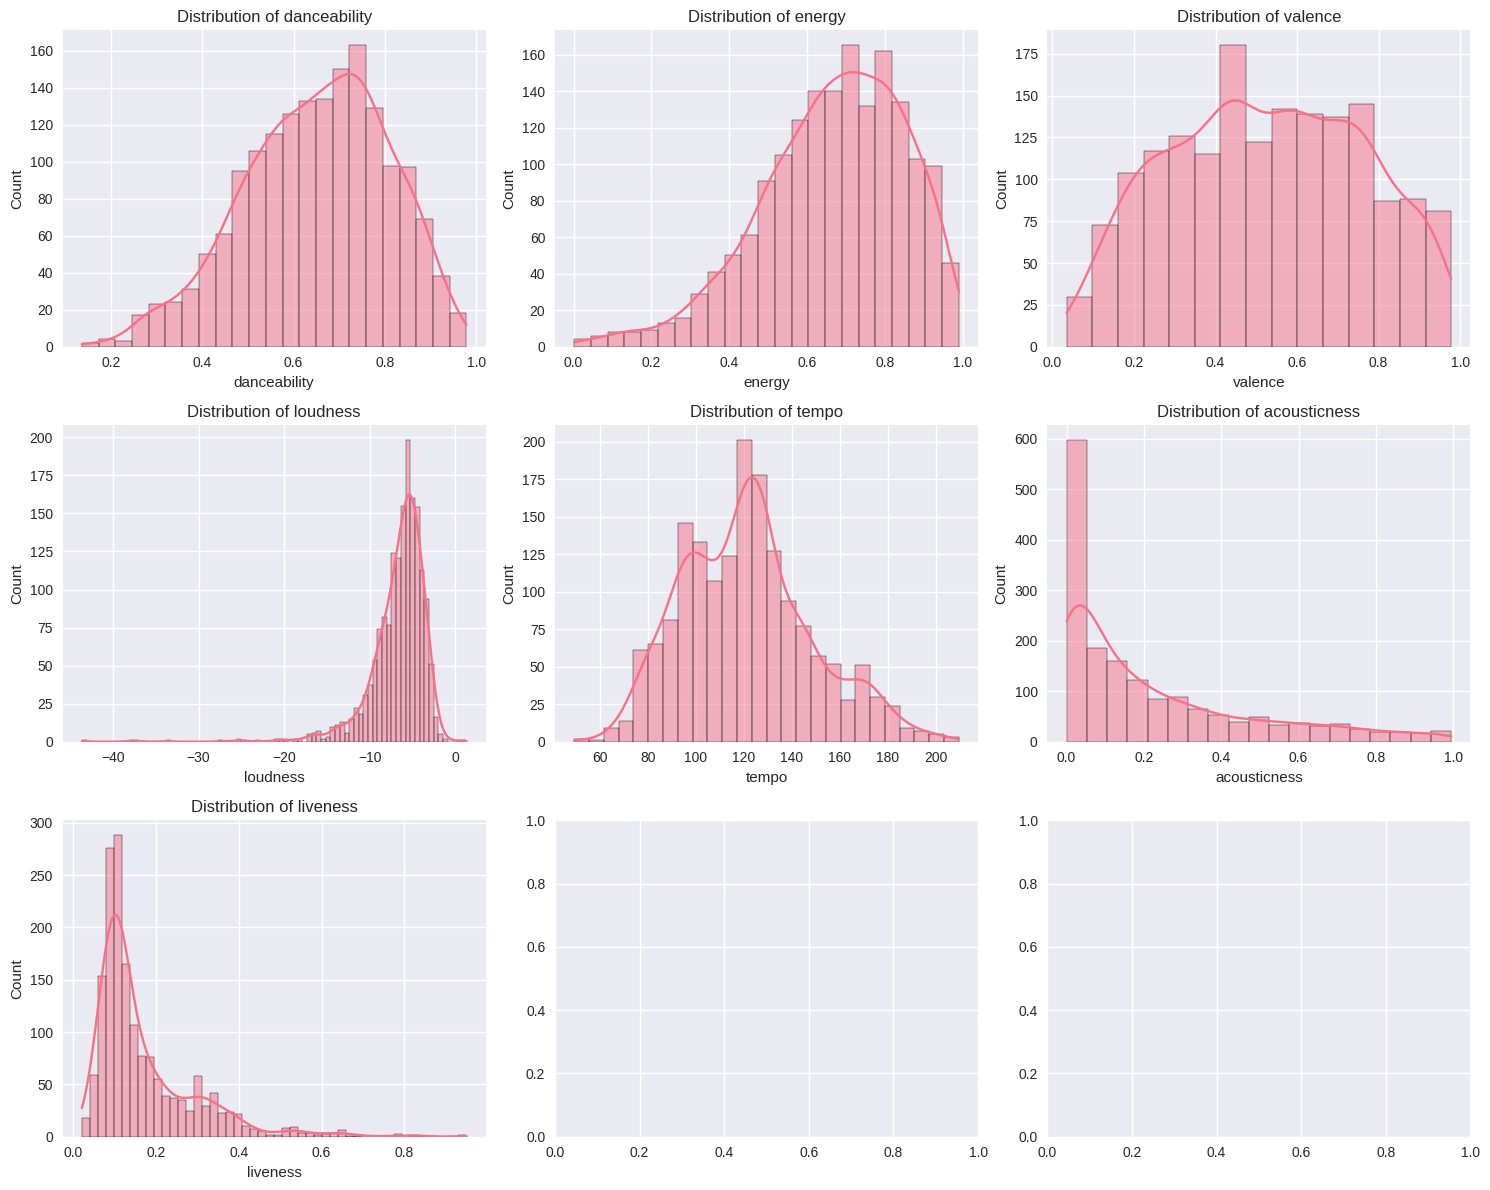

In [7]:
## Распределения аудио-фич
audio_features = ['danceability', 'energy', 'valence', 'loudness', 'tempo', 'acousticness', 'liveness']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, feature in enumerate(audio_features):
    if feature in df.columns:
        sns.histplot(df[feature], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {feature}')
    else:
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()

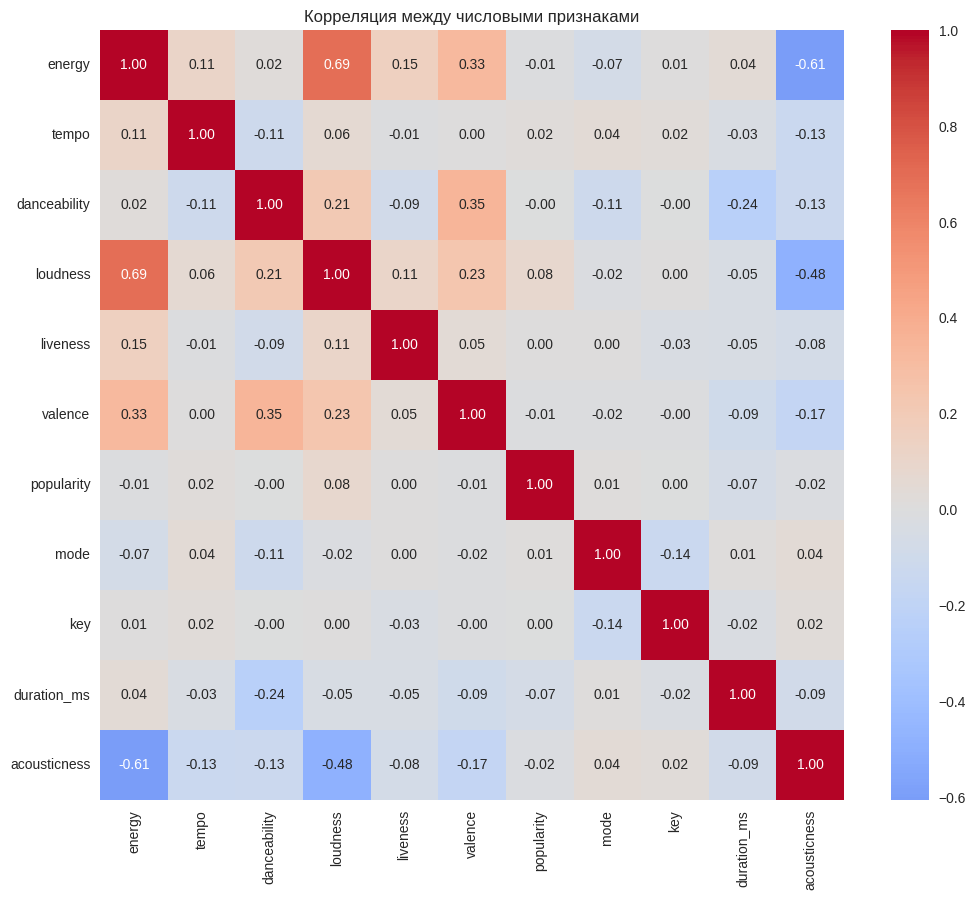

In [8]:
# Корреляционная матрица
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляция между числовыми признаками')
plt.show()

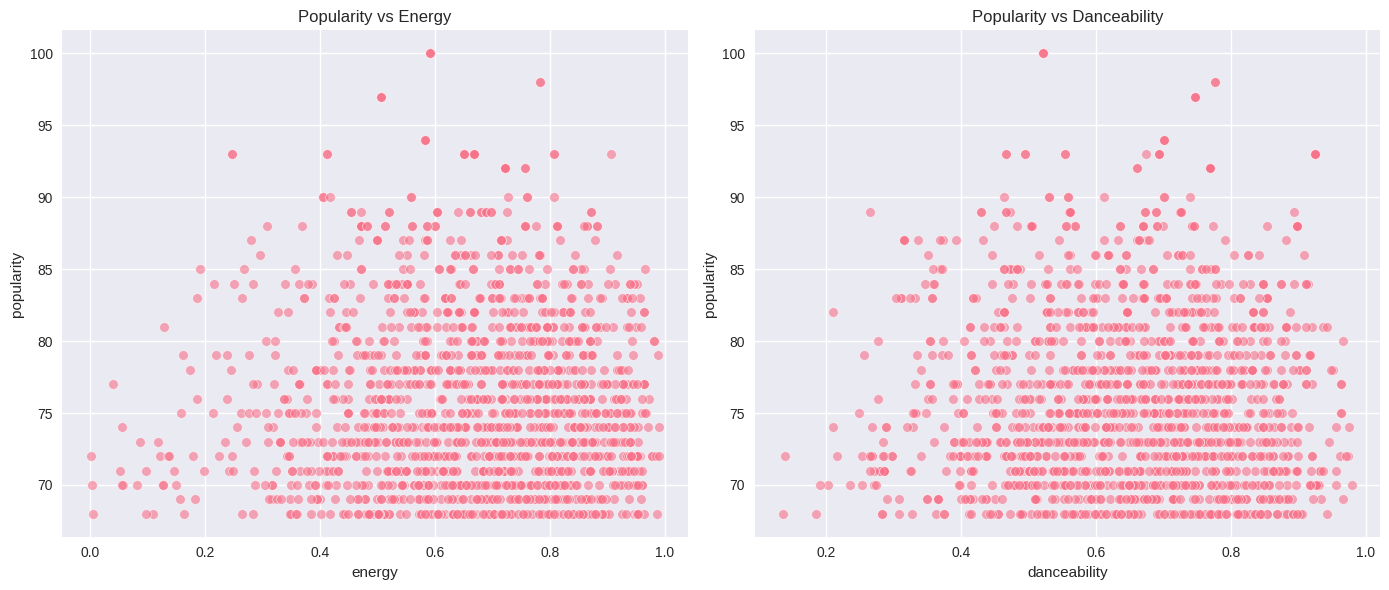

In [9]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='energy', y='popularity', alpha=0.6)
plt.title('Popularity vs Energy')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='danceability', y='popularity', alpha=0.6)
plt.title('Popularity vs Danceability')

plt.tight_layout()
plt.show()

Распределение по настроениям:
inferred_mood
neutral        561
happy          321
energetic      301
dance          210
romantic       111
melancholic    101
ecstatic        81
Name: count, dtype: int64


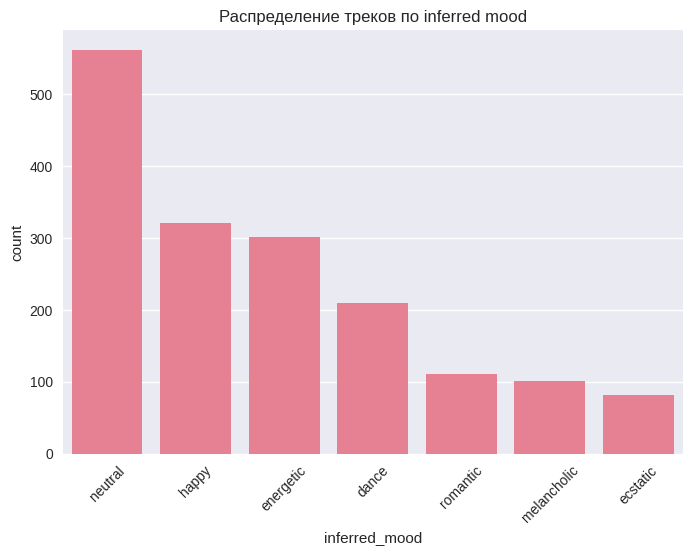

In [10]:
def infer_mood(row):
    energy = row.get('energy', 0.5)
    valence = row.get('valence', 0.5)
    dance = row.get('danceability', 0.5)

    if energy > 0.8 and valence > 0.8:
        return 'ecstatic'
    elif energy > 0.7 and valence > 0.6:
        return 'happy'
    elif energy > 0.75:
        return 'energetic'
    elif energy < 0.4 and valence < 0.4:
        return 'melancholic'
    elif dance > 0.8:
        return 'dance'
    elif valence > 0.7:
        return 'romantic'
    else:
        return 'neutral'

df['inferred_mood'] = df.apply(infer_mood, axis=1)

print("Распределение по настроениям:")
print(df['inferred_mood'].value_counts())

sns.countplot(data=df, x='inferred_mood', order=df['inferred_mood'].value_counts().index)
plt.title('Распределение треков по inferred mood')
plt.xticks(rotation=45)
plt.show()

## Ключевые выводы EDA

1. Датасет содержит **высокопопулярные треки** — хорошее качество данных.
2. Есть сильная корреляция между `energy`, `danceability` и `valence`.
3. Популярность слабо коррелирует с отдельными фичами — нужна комбинация + семантический поиск.
4. Жанровое разнообразие хорошее (pop, rap, rock, electronic и др.).
5. Можно использовать аудио-фичи для дополнительной фильтрации/реранжирования.
6. Rule-based mood detector работает разумно как fallback.
